In [96]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [ ]:
atten_path= "atten_path"
data_dir="data_dir"

atten_scores = np.load(os.path.join(atten_path,"atten.npy"))
atten_token= np.load(os.path.join(atten_path,"atten_token_based.npy"))
pred_results = np.load(os.path.join(atten_path,"pred_results.npy"))


data = pd.read_csv(os.path.join(data_dir,"test_window.tsv"),sep='\t',header=0)
data['pred'] = pred_results
data['pred'] = data['pred'].apply(lambda x: 1 if x>0.5 else 0)
file_path = os.path.join(atten_path,"tokenized_test_set.txt")
with open(file_path, 'r') as file:
    tokenized_train_set = file.read().split('\n')

tokens = [token for i, token in enumerate(tokenized_train_set) if i in data.index]
data['tokens'] = tokens
data['seq_len'] = 0
for i, row in data.iterrows():
    seq = row['tokens']
    pads = 0
    pads += seq.count("[PAD]")
    len_seq = len(seq.split()) - pads
    data.at[i, 'seq_len'] = len_seq

print(data)
atten_token.shape

     chr    start      end                                                seq  \
0     13   363312   363811  ATGCATTACAAATTTGTATTTGATTCTATATATAGTTTCGTTATAT...   
1      4   483669   484168  TTGATTTATACCATTTTGAAATCTAATCTTGCTCCAAGGGAGAAGC...   
2      7  1056150  1056649  CCTTGTAGTTGTCCTGCAAAGATGGGTAGGTATTTTCCTTGATATG...   
3     15   766442   766941  CAGTTTACAAGAATCACAACAAAAGGCGCCTTTGCAGAGGCCCCTT...   
4      4   638559   639058  CTCTAACTAATACAAACTCCTTACTATCTAATATAACGGCTACATC...   
..   ...      ...      ...                                                ...   
125   10    18014    18513  AGTAAAACTCTTGTGTCTTTTCATCGAACGTCCATGCAGAACCACC...   
126   16   698214   698713  TAAGCTCTGAGGGGCTTAATACTGTTGGTAAGACTCCAGAAATCGT...   
127   16   339219   339718  CTGGACCGCCCGGTAAGTTCTGCTATTAACAAATTAAATAAAATTG...   
128    4  1252944  1253443  AGAGGTCATTGTTCAAAGTGAGTTGGTGAGTTTTGGTCGGATACCC...   
129    8   555958   556457  ACATAACTGAATGTTAAAATGGCATCATCAATACAGTATTACTGAT...   

     label  pred           

(130, 114)

In [98]:


dev_pos = data[data['label'] == 1]
dev_neg = data[data['label'] == 0]
pos_atten_scores = atten_scores[dev_pos.index.values]
neg_atten_scores = atten_scores[dev_neg.index.values]

pos_atten_token = atten_token[dev_pos.index.values]


neg_atten_token = atten_token[dev_neg.index.values]

dev_pos.reset_index(drop=True, inplace=True)
dev_neg.reset_index(drop=True, inplace=True)

print(dev_pos)
print(pos_atten_token.shape)

    chr   start     end                                                seq  \
0     4  483669  484168  TTGATTTATACCATTTTGAAATCTAATCTTGCTCCAAGGGAGAAGC...   
1    15  766442  766941  CAGTTTACAAGAATCACAACAAAAGGCGCCTTTGCAGAGGCCCCTT...   
2    15  337119  337618  AAGAACCAGTGCAGGATATATATTATTTCCCACGGTTTTTCTCCAC...   
3     7  607176  607675  AAATAGAAGAGGTAAACCAATCAATGGCCCGTTAGTTTGCCATTTG...   
4     6  256090  256589  GCATGGAAGATATTCCGGGGTTGTTTAACAATAAACGTGTAGAGTA...   
..  ...     ...     ...                                                ...   
60    4   15368   15867  AAAAAATTAGAGATTCATTGAATCTCTAATTTATTTAAAGTTTATA...   
61    8  359441  359940  CATCTCCTTATACTGTATATGATAATATACTGGTGGTGAATGACAG...   
62   10  336811  337310  CTAATGTAATGACAGATTCCACTGCTATCCGATACGAAATAATGGA...   
63   16  842595  843094  TGGCTGAGAGGAATTCTAAGATTTCTAATGTGGAGAGGTATACTCT...   
64    8  555958  556457  ACATAACTGAATGTTAAAATGGCATCATCAATACAGTATTACTGAT...   

    label  pred                                             tok

(65, 500)


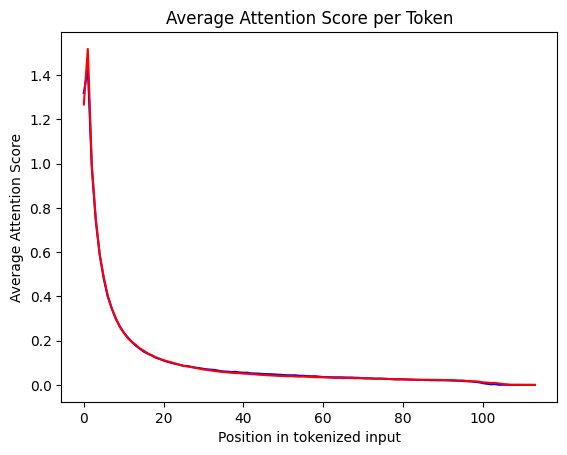

(65, 500)

In [66]:


# Compute the mean attention score across positive instances for each position
mean_attention_pos = np.mean(pos_atten_token, axis=0)
mean_attention_pos.shape

plt.plot(mean_attention_pos, color='b')
plt.title('Average Attention Score per Token')
plt.xlabel('Position in Sequence')
plt.ylabel('Average Attention Score')
# plt.show()
print(pos_atten_scores.shape)

# Compute the mean attention score across negative instances for each position
mean_attention_neg = np.mean(neg_atten_token, axis=0)
mean_attention_neg.shape

plt.plot(mean_attention_neg, color='r')

plt.xlabel('Position in tokenized input')
plt.ylabel('Average Attention Score')
plt.show()
neg_atten_scores.shape

(65, 500)


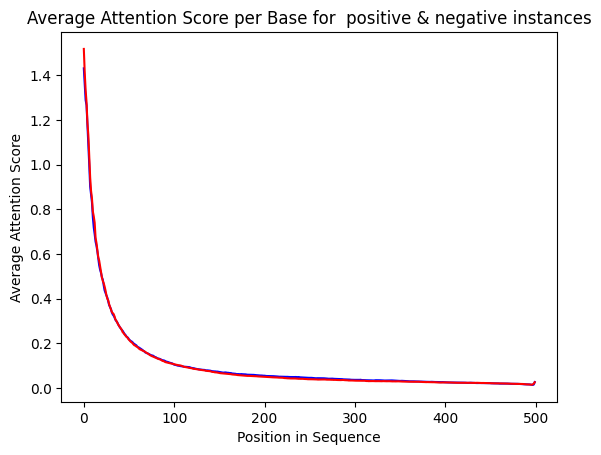

(65, 500)

In [67]:


# Compute the mean attention score across positive instances for each position
mean_attention_pos = np.mean(pos_atten_scores, axis=0)
mean_attention_pos.shape

plt.plot(mean_attention_pos, color='b')
plt.title('Average Attention Score per Base for positive instances')
plt.xlabel('Position in Sequence')
plt.ylabel('Average Attention Score')
# plt.show()
print(pos_atten_scores.shape)

# Compute the mean attention score across negative instances for each position
mean_attention_neg = np.mean(neg_atten_scores, axis=0)
mean_attention_neg.shape

plt.plot(mean_attention_neg, color='r')
plt.title('Average Attention Score per Base for  positive & negative instances')
plt.xlabel('Position in Sequence')
plt.ylabel('Average Attention Score')
plt.show()
neg_atten_scores.shape

In [99]:
original_origin=pd.read_csv("/p/project1/hai_dnaori/piroozeh1/yeast-origins/data/yeast_oridb_confirmed_Less500.csv")
original_origin.head(6)

,chr,start,end,name,length
0,1,30946,31184,"104,00 ARS",239
1,1,70258,70491,"106,00 ARS",234
2,1,124350,124599,"107,00 ARS",250
3,1,159906,160127,"109,00 ARS",222
4,1,176154,176402,"110,00 ARS",249
5,2,28933,29152,ARS201.5,220


chr                                                        4
start                                                 483669
end                                                   484168
seq        TTGATTTATACCATTTTGAAATCTAATCTTGCTCCAAGGGAGAAGC...
label                                                      1
pred                                                       0
tokens     [CLS] TT GATT TATA CCATTTT GAAA TCTAA TCTT GCT...
seq_len                                                  106
Name: 0, dtype: object
<class 'int'>


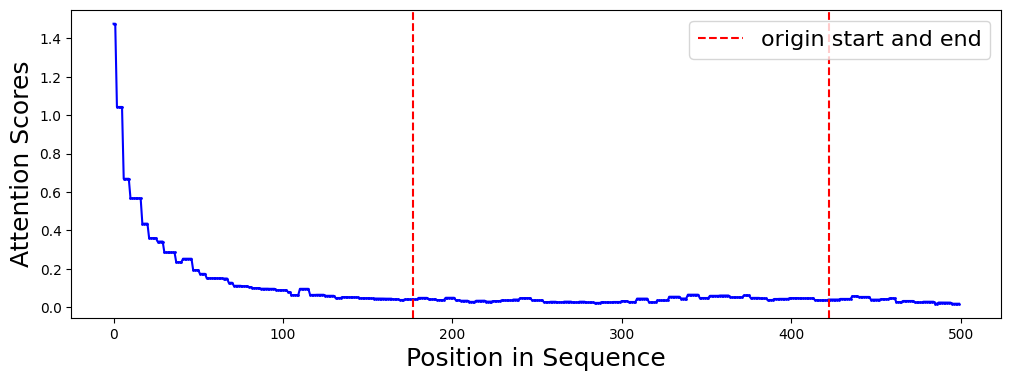

chr                                                       15
start                                                 766442
end                                                   766941
seq        CAGTTTACAAGAATCACAACAAAAGGCGCCTTTGCAGAGGCCCCTT...
label                                                      1
pred                                                       1
tokens     [CLS] CAGTT TACAA GAA TCACAA CAAAA GGCGCC TTTG...
seq_len                                                   99
Name: 1, dtype: object
<class 'int'>


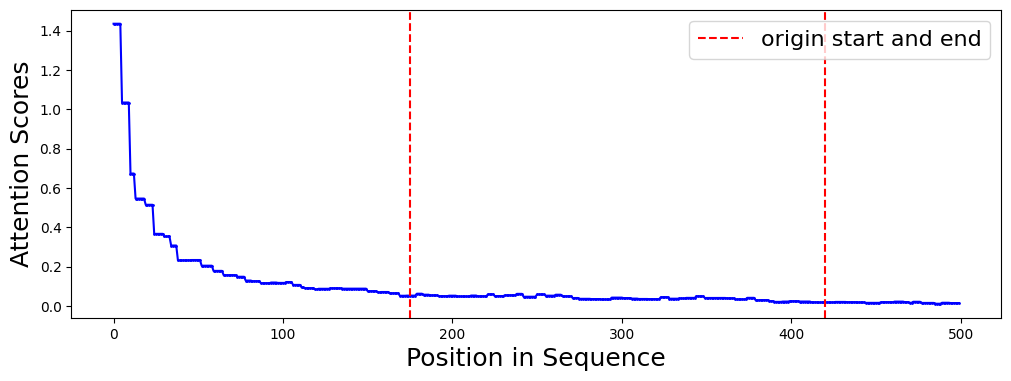

In [100]:
# attention maps with the dnabert motifs and homer motifs
for i, sample in dev_pos.iterrows():
    if i <2:
        scores= pos_atten_scores[i]
        # scores=scores*12
        print(sample)
        sequence=sample['seq']
        scores_token= pos_atten_token[i]
        sequence= sample['seq']
        
        tokenized = sample['tokens'].split()
        start=sample['start']
        end=sample['end']
        print(type(end))
        #find origin actual range
        matching_rows = original_origin[(original_origin['chr'] == sample['chr']) & (original_origin['start'] >= start) & (original_origin['end'] <= end)]
        if not matching_rows.empty:
            origin_start = matching_rows['start'].values[0]-start
            origin_end = matching_rows['end'].values[0]-start
           


        plt.figure(figsize=(12, 4))
        plt.plot(range(len(sequence)), scores, marker='o', linestyle='-', color='b', markersize=1)
    
        plt.axvline(x=origin_start, color='red', linestyle='--', label='origin start and end')
        plt.axvline(x=origin_end, color='red', linestyle='--')
        plt.xlabel('Position in Sequence',fontsize=18)
        plt.ylabel('Attention Scores', fontsize=18)
        # plt.title("Attention Scores Along DNA Sequence chr{}-{}-{}".format(str(sample['chr']), start, end),fontsize=20)
        # plt.xticks(range(len(sequence)), sequence)
        plt.legend(fontsize=16)
        plt.show()
        # plt.figure(figsize=(12, 4))
        # plt.plot(range(len(tokenized)),  scores_token, marker='o', linestyle='-', color='b', markersize=1)

        # plt.xlabel('Position in Tokenized Sequence', fontsize=18)
        # plt.ylabel('Attention Scores', fontsize=18)
        # plt.title("Attention Scores Along DNA Sequence chr{}-{}-{}".format(str(sample['chr']), start, end), fontsize=20)
        # # plt.xticks(range(len(tokenized)), tokenized)
        # plt.legend()
        # plt.show()
        

       
        # scores_token=scores_token.reshape(1, scores_token.shape[0])
        # sns.heatmap(scores_token,   cmap='viridis', vmin=0)
        # plt.title('Attention Heatmap per token')
        # plt.show()